# Crawling Berita Detik.com: Sport dan Finance

Notebook ini membahas proses **Web Search & Mining** untuk mengumpulkan berita dari detik.com menggunakan pendekatan CRISP-DM sampai tahap **Data Preparation**. Dataset digunakan untuk membandingkan karakteristik berita kategori sport dan finance.

## Business Understanding

### Latar Belakang

Berita online memiliki jumlah dan topik yang terus bertambah. Pengelompokan berita berdasarkan kategori dapat membantu proses pencarian informasi, pengarsipan, analisis tren, dan pengembangan sistem rekomendasi atau klasifikasi berita.

### Tujuan

Tujuan proyek ini adalah membangun dataset berita berbahasa Indonesia dari detik.com yang terdiri dari dua kategori:

- 100 berita `sport` dari [detikSport](https://sport.detik.com/)
- 100 berita `finance` dari [detikFinance](https://finance.detik.com/)

Setiap berita disimpan dengan kolom `id`, `isi_berita`, `label`, dan `url`.

### Pertanyaan yang Ingin Dijawab

1. Apakah data berita dari kategori sport dan finance dapat dikumpulkan secara seimbang?
2. Seperti apa perbedaan panjang isi berita pada kedua kategori?
3. Kata atau topik apa yang paling sering muncul pada masing-masing kategori?
4. Apakah dataset sudah cukup bersih dan lengkap untuk digunakan pada tahap analisis berikutnya?

### Kriteria Keberhasilan

Proses crawling dianggap berhasil apabila:

- tersedia 200 artikel unik;
- terdapat tepat 100 artikel dengan label `sport` dan 100 artikel dengan label `finance`;
- setiap baris memiliki `id`, isi berita, label, dan URL lengkap;
- tidak ada URL duplikat;
- tidak ada isi berita yang kosong;
- isi artikel sudah dipisahkan dari navigasi, iklan, dan elemen HTML yang tidak diperlukan.

## Data Understanding

Data diperoleh dari halaman kategori dan indeks berita detik.com. URL sumber setiap artikel dipertahankan pada kolom `url` agar proses pengumpulan dapat ditelusuri dan diverifikasi.

### Struktur Dataset

| Kolom | Tipe | Keterangan |
| --- | --- | --- |
| `id` | string | Identitas unik, yaitu `SP001`-`SP100` atau `FN001`-`FN100` |
| `isi_berita` | text | Judul dan isi utama artikel yang sudah dibersihkan |
| `label` | category | Kategori berita: `sport` atau `finance` |
| `url` | string | URL lengkap artikel dari detik.com |

### Pemeriksaan Awal

Pemeriksaan awal meliputi jumlah data, distribusi label, nilai kosong, URL duplikat, duplikat isi berita, panjang teks, serta contoh isi artikel. Hasil pemeriksaan dan grafik ditampilkan pada sel-sel berikutnya.

### Data Preparation Sederhana

Pada tahap ini dilakukan pembersihan ringan, yaitu menghapus tag HTML dan elemen non-berita, merapikan spasi, mengabaikan artikel yang terlalu pendek, serta menghindari URL duplikat. Tokenisasi, TF-IDF, dan pembagian data latih-uji belum dilakukan karena notebook ini berhenti pada tahap pemahaman data.

In [1]:
%pip install pandas requests beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [4]:
import re
import time
from urllib.parse import urljoin, urlparse

import pandas as pd
import requests
from bs4 import BeautifulSoup
from IPython.display import display

HEADERS = {"User-Agent": "Mozilla/5.0 (educational web-mining project)"}
TARGET_PER_LABEL = 100
REQUEST_DELAY = 1
SOURCES = {
    "sport": {
        "start_urls": ["https://sport.detik.com/"] + [f"https://sport.detik.com/indeks?page={page}" for page in range(1, 8)],
        "domain": "sport.detik.com",
    },
    "finance": {
        "start_urls": ["https://finance.detik.com/"] + [f"https://finance.detik.com/indeks?page={page}" for page in range(1, 8)],
        "domain": "finance.detik.com",
    },
}
session = requests.Session()
session.headers.update(HEADERS)


def get_soup(url):
    response = session.get(url, timeout=30)
    response.raise_for_status()
    return BeautifulSoup(response.text, "html.parser")


def is_article_url(url, domain):
    parsed = urlparse(url)
    return (parsed.scheme in {"http", "https"} and parsed.netloc == domain
            and re.search(r"/d-\d+[-/]", parsed.path) is not None)


def collect_article_links(start_urls, domain, max_pages=12):
    links, pages_seen, pending = set(), set(), list(start_urls)
    while pending and len(pages_seen) < max_pages and len(links) < TARGET_PER_LABEL * 3:
        page_url = pending.pop(0)
        if page_url in pages_seen:
            continue
        pages_seen.add(page_url)
        try:
            soup = get_soup(page_url)
        except requests.RequestException as error:
            print(f"Gagal membuka {page_url}: {error}")
            continue
        for anchor in soup.select("a[href]"):
            raw_url = urljoin(page_url, anchor["href"])
            article_url = raw_url.split("?")[0].split("#")[0]
            if is_article_url(article_url, domain):
                links.add(article_url)
            elif urlparse(raw_url).netloc == domain and "/indeks" in urlparse(raw_url).path:
                if raw_url not in pages_seen:
                    pending.append(raw_url)
        time.sleep(REQUEST_DELAY)
    return sorted(links)


def extract_article_text(url):
    soup = get_soup(url)
    title_node = soup.select_one("h1")
    body = soup.select_one(".detail__body-text, .detail__body, .itp_bodycontent, article")
    if body is None:
        return ""
    for node in body.select("script, style, aside, iframe, figure, .detail__media, .parallax, .ad-container"):
        node.decompose()
    text = re.sub(r"\s+", " ", body.get_text(" ", strip=True)).strip()
    title = title_node.get_text(" ", strip=True) if title_node else ""
    return f"{title}. {text}" if title and title.lower() not in text.lower() else text


def crawl_category(label, config, target=TARGET_PER_LABEL):
    links = collect_article_links(config["start_urls"], config["domain"])
    rows, seen_urls = [], set()
    prefix = "SP" if label == "sport" else "FN"
    print(f"{label}: ditemukan {len(links)} URL kandidat")
    for url in links:
        if len(rows) >= target or url in seen_urls:
            break
        seen_urls.add(url)
        try:
            text = extract_article_text(url)
            if len(text) < 200:
                continue
            rows.append({"id": f"{prefix}{len(rows) + 1:03d}", "isi_berita": text,
                         "label": label, "url": url})
            print(f"{label}: {len(rows)}/{target}", end="\r")
            time.sleep(REQUEST_DELAY)
        except requests.RequestException as error:
            print(f"\nGagal mengambil {url}: {error}")
    print(f"\n{label}: berhasil dikumpulkan {len(rows)} artikel")
    return rows


all_rows = []
for label, config in SOURCES.items():
    all_rows.extend(crawl_category(label, config))

dataset = pd.DataFrame(all_rows, columns=["id", "isi_berita", "label", "url"])
dataset.to_csv("dataset_detik.csv", index=False, encoding="utf-8-sig")
display(dataset.head())

Gagal membuka https://sport.detik.com/: HTTPSConnectionPool(host='sport.detik.com', port=443): Read timed out. (read timeout=30)
sport: ditemukan 183 URL kandidat
sport: 100/100
sport: berhasil dikumpulkan 100 artikel
finance: ditemukan 207 URL kandidat
finance: 72/100
Gagal mengambil https://finance.detik.com/berita-ekonomi-bisnis/d-8653993/bandara-soetta-sempat-ditutup-barang-ekspor-impor-rp-3-t-mandek: HTTPSConnectionPool(host='finance.detik.com', port=443): Read timed out.
finance: 100/100
finance: berhasil dikumpulkan 100 artikel


,id,isi_berita,label,url
0,SP001,Menkomdigi Imbau Warga Waspadai Dampak Erupsi ...,sport,https://sport.detik.com/advertorial-news-block...
1,SP002,Asian Games 2026: Timnas Basket Masuk Grup Ner...,sport,https://sport.detik.com/basket/d-8649778/asian...
2,SP003,Derrick Michael Wujudkan Mimpi Masa Kecil Tamp...,sport,https://sport.detik.com/basket/d-8649812/derri...
3,SP004,"Timnas Basket Putra di Asian Games 2026, Menan...",sport,https://sport.detik.com/basket/d-8653694/timna...
4,SP005,Timnas Basket Jadi Gelombang Pertama Datang ke...,sport,https://sport.detik.com/basket/d-8654249/timna...


## Data Understanding dan Data Preparation

Struktur data akhir adalah `id`, `isi_berita`, `label`, dan `url`. Tahap persiapan membersihkan HTML, menghapus artikel terlalu pendek, menghindari URL duplikat, dan membagi data secara stratified untuk modeling.

In [3]:
import pandas as pd
from IPython.display import display

dataset = pd.read_csv("dataset_detik.csv")
dataset.info()
display(dataset["label"].value_counts().rename_axis("label").to_frame("jumlah"))

dataset["panjang_teks"] = dataset["isi_berita"].str.len()
print("Duplikat URL:", dataset["url"].duplicated().sum())
print("Duplikat isi berita:", dataset["isi_berita"].duplicated().sum())
display(dataset[["id", "label", "url", "isi_berita"]].head(10))

assert set(dataset.columns) == {"id", "isi_berita", "label", "url", "panjang_teks"}
assert dataset["url"].is_unique
assert dataset["isi_berita"].notna().all()
assert dataset["url"].str.startswith("http").all()
assert dataset["label"].value_counts().to_dict() == {"sport": 100, "finance": 100}, (
    "Target belum terpenuhi. Tambahkan halaman sumber pada SOURCES atau ulangi crawling."
)
print("Validasi berhasil: 200 artikel unik, 100 sport, 100 finance.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    object
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
 3   url         200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB


,jumlah
label,
sport,100
finance,100


Duplikat URL: 0
Duplikat isi berita: 0


,id,label,url,isi_berita
0,SP001,sport,https://sport.detik.com/advertorial-news-block...,Menkomdigi Imbau Warga Waspadai Dampak Erupsi ...
1,SP002,sport,https://sport.detik.com/basket/d-8649778/asian...,Asian Games 2026: Timnas Basket Masuk Grup Ner...
2,SP003,sport,https://sport.detik.com/basket/d-8649812/derri...,Derrick Michael Wujudkan Mimpi Masa Kecil Tamp...
3,SP004,sport,https://sport.detik.com/basket/d-8653694/timna...,"Timnas Basket Putra di Asian Games 2026, Menan..."
4,SP005,sport,https://sport.detik.com/basket/d-8654249/timna...,Timnas Basket Jadi Gelombang Pertama Datang ke...
5,SP006,sport,https://sport.detik.com/detiktv/d-7531855/dua-...,Video 20Detik Dua Kali Ganti Motor Bikin Jorge...
6,SP007,sport,https://sport.detik.com/f1/d-8651436/hasil-f1-...,Hasil F1 GP Italia 2026: Kimi Antonelli Menang...
7,SP008,sport,https://sport.detik.com/f1/d-8651642/mamma-mia...,"Mamma Mia, Antonelli Mohammad Resha Pratama - ..."
8,SP009,sport,https://sport.detik.com/fotosport/d-7531488/me...,Foto Sport Meriahnya Penutupan Paralimpiade 20...
9,SP010,sport,https://sport.detik.com/fotosport/d-7531548/pa...,"Foto Sport Paralimpiade Paris 2024 Usai, Indon..."


Validasi berhasil: 200 artikel unik, 100 sport, 100 finance.


Statistik panjang isi berita:


,jumlah,rata_rata,median,minimum,maksimum
label,,,,,
finance,100,2965.0,2716.0,1134,8713
sport,100,2265.0,2333.0,380,3958


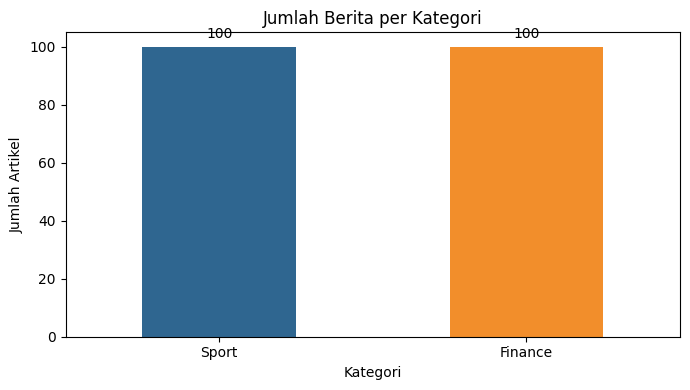

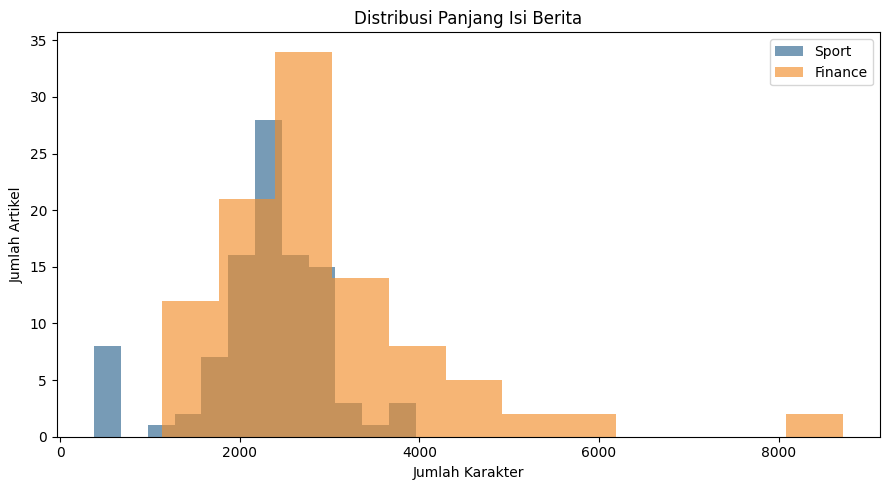

<Figure size 700x400 with 0 Axes>

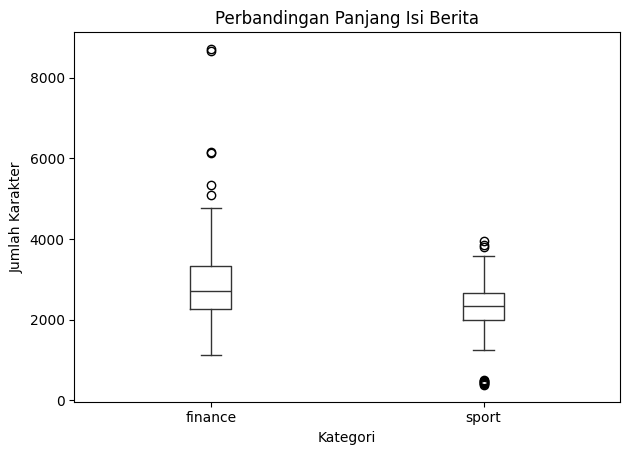

Kata yang paling sering muncul setelah stopword removal:


,sport,finance
motogp,447,0
marquez,324,0
aragon,286,0
marc,261,0
balapan,162,0
martin,144,0
wib,138,169
indonesia,133,197
bezzecchi,128,0
posisi,120,0


In [5]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Ringkasan statistik panjang teks per kategori.
ringkasan_teks = dataset.groupby("label")["panjang_teks"].agg(
    jumlah="count",
    rata_rata="mean",
    median="median",
    minimum="min",
    maksimum="max",
).round(0)
print("Statistik panjang isi berita:")
display(ringkasan_teks)

# Grafik 1: jumlah artikel pada setiap label.
jumlah_label = dataset["label"].value_counts().reindex(["sport", "finance"])
plt.figure(figsize=(7, 4))
ax = jumlah_label.plot(kind="bar", color=["#2f6690", "#f28e2b"])
ax.set_title("Jumlah Berita per Kategori")
ax.set_xlabel("Kategori")
ax.set_ylabel("Jumlah Artikel")
ax.set_xticklabels(["Sport", "Finance"], rotation=0)
for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", xytext=(0, 4), textcoords="offset points",
    )
plt.tight_layout()
plt.show()

# Grafik 2: distribusi panjang isi berita.
plt.figure(figsize=(9, 5))
for label, color in [("sport", "#2f6690"), ("finance", "#f28e2b")]:
    plt.hist(
        dataset.loc[dataset["label"] == label, "panjang_teks"],
        bins=12,
        alpha=0.65,
        label=label.title(),
        color=color,
    )
plt.title("Distribusi Panjang Isi Berita")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Jumlah Artikel")
plt.legend()
plt.tight_layout()
plt.show()

# Grafik 3: boxplot untuk membandingkan panjang teks antar kategori.
plt.figure(figsize=(7, 4))
dataset.boxplot(column="panjang_teks", by="label", grid=False, color="#333333")
plt.suptitle("")
plt.title("Perbandingan Panjang Isi Berita")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Karakter")
plt.tight_layout()
plt.show()

# Tabel kata yang sering muncul sebagai gambaran topik awal.
stopwords_id = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan",
    "pada", "dalam", "atau", "juga", "akan", "ada", "sebagai", "lebih",
    "sudah", "telah", "tidak", "karena", "oleh", "saat", "hingga", "dapat",
    "bisa", "jadi", "para", "nya", "ia", "tak", "tersebut", "mereka",
    "tautan", "disalin", "artikel", "baca", "saya", "selengkapnya", "detik",
}


def kata_teratas(label, jumlah=10):
    teks = dataset.loc[dataset["label"] == label, "isi_berita"].str.lower()
    kata = re.findall(r"[a-zA-ZÀ-ÿ]{3,}", " ".join(teks))
    kata = [item for item in kata if item not in stopwords_id]
    return Counter(kata).most_common(jumlah)


frekuensi_kata = pd.DataFrame({
    "sport": dict(kata_teratas("sport")),
    "finance": dict(kata_teratas("finance")),
}).fillna(0).astype(int)
print("Kata yang paling sering muncul setelah stopword removal:")
display(frekuensi_kata.sort_values(["sport", "finance"], ascending=False).head(10))